In [1]:
import copy
import sys
import os
import warnings
warnings.filterwarnings('ignore')

from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

from statsforecast.arima import arima_string
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.multitest import multipletests

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse


sys.path.append(os.path.join(os.getcwd(), ".."))


from src.preprocessing import preporocess, take_n

In [2]:
df = pd.read_csv("../data/kz.csv")
df = preporocess(df)

## Take n best sold

In [3]:
prod_idx, prod_list, nr_orders_week  = take_n(df, 100)

In [4]:
prod_list[prod_idx[0]].head()

date
2020-01-12      9
2020-01-19    150
2020-01-26    322
2020-02-02    177
2020-02-09    143
Name: order_nr, dtype: int64

## Auto ARIMA

In [5]:
# structure df in to a format required for the statsforecast
df_for_fit = pd.DataFrame({
    "unique_id": nr_orders_week.index.get_level_values(0),
    "ds": nr_orders_week.index.get_level_values(1),
    "y": nr_orders_week.values
})
print(df_for_fit.head())

             unique_id          ds    y
0  1515966223509088521  2020-01-12    9
1  1515966223509088521  2020-01-19  150
2  1515966223509088521  2020-01-26  322
3  1515966223509088521  2020-02-02  177
4  1515966223509088521  2020-02-09  143


From the first notebook "demand_forecast.ipynb" it can be seen that many of series have three periods with higher values. We will take a quartile freaquency wich could describe this situation. One quartile is 3 months which is approximately 13 weeks.

In [23]:
# fit ARIMA for every series with AutoARIMA 
sf = StatsForecast(
    models=[
        AutoARIMA(
            season_length=13,
            start_p=0,
            start_q=0,
            max_d=2
        )
    ],
    freq="W",
    n_jobs=-1
)

sf.fit(df_for_fit);

In [24]:
# test each series with maximal lag = 15 and inspect smallest p-value

p_values = []

for i in range(100):
    res = sf.fitted_[i, 0].model_["residuals"]
    val = acorr_ljungbox(res, lags=15).lb_pvalue.min()
    if val < 0.01:
        print(f"{i}. {np.round(val, 5)}  **")
    elif val < 0.05:
        print(f"{i}. {np.round(val, 5)}  *")
    p_values.append(val)


16. 0.03338  *
33. 0.03335  *
42. 0.04181  *
47. 0.02808  *
53. 0.01191  *
54. 0.01436  *
60. 0.00992  **
62. 0.03011  *
70. 0.0007  **
75. 0.03498  *
84. 0.01065  *
91. 0.01  **
95. 0.0307  *


In [25]:
cv = sf.cross_validation(
    df=df_for_fit,
    h=8,
    n_windows=3
)

## Prediction accuracy

In [27]:

mae_by_series = (
    cv.groupby("unique_id")
      .apply(
          lambda x: 
              (abs(x["y"] - x["AutoARIMA"])).mean()
      )
      .rename("MAE")
)

mae_sorted = mae_by_series.sort_values(ascending=False)
for id_val, val in zip(mae_sorted.index, mae_sorted):
    print(prod_idx.get_loc(id_val), val)

49 1533.5103759765625
60 615.822998046875
66 595.0128784179688
65 567.4583129882812
70 562.5592651367188
63 550.7034301757812
41 525.3147583007812
61 470.105224609375
97 436.4269104003906
5 390.80859375
43 388.8355407714844
56 360.2747497558594
78 282.5636291503906
69 264.2323913574219
12 261.3370056152344
67 230.0416717529297
80 222.5138702392578
55 183.15480041503906
22 177.09950256347656
58 174.125
0 160.26820373535156
21 152.75465393066406
11 150.6666717529297
2 142.7083282470703
1 123.58402252197266
24 119.25
36 118.36648559570312
17 115.96088409423828
8 110.54166412353516
10 109.2812728881836
9 105.5223617553711
59 104.887451171875
94 102.53914642333984
85 93.60980987548828
16 92.33333587646484
76 91.1778335571289
14 85.74212646484375
72 83.27737426757812
86 80.928955078125
28 79.4594497680664
99 79.24925994873047
68 79.06275177001953
32 70.94091033935547
31 70.85135650634766
29 69.95758056640625
13 68.52071380615234
37 67.7679672241211
30 67.63053131103516
27 65.47782135009766
9

In [11]:
scale_param = 0.1
am = arch_model(prod_list[prod_idx[69]].diff(1).dropna() * scale_param, mean="Zero", vol="GARCH")
res = am.fit(disp='off')
res

                       Zero Mean - GARCH Model Results                        
Dep. Variable:               order_nr   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.022
Vol Model:                      GARCH   Log-Likelihood:               -236.739
Distribution:                  Normal   AIC:                           479.478
Method:            Maximum Likelihood   BIC:                           484.964
                                        No. Observations:                   46
Date:                Thu, Jul 09 2026   Df Residuals:                       46
Time:                        08:58:46   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega        541.7153    375.259      1.444      0.149 

In [12]:
ser = prod_list[prod_idx[69]].diff(1).dropna()

tests, forecast, mae = mae_crossval(ser, n_splits=5, scale_param=0.1)

sum(mae) / len(mae)

NameError: name 'mae_crossval' is not defined

In [ ]:
forecast

In [ ]:
tests

## The series with the worst prediction strength

In [40]:
k = 49

# fit ARIMA for every series with AutoARIMA 
sf_k = StatsForecast(
    models=[
        AutoARIMA(
            season_length=13,
            start_p=0,
            start_q=0,
            max_d=2
        )
    ],
    freq="W",
    n_jobs=-1
)

sf_k.fit(df_for_fit[df_for_fit["unique_id"] == prod_idx[k]]);

In [41]:
cv = sf_k.cross_validation(
    df=df_for_fit[df_for_fit["unique_id"] == prod_idx[k]],
    h=8,
    n_windows=3
)

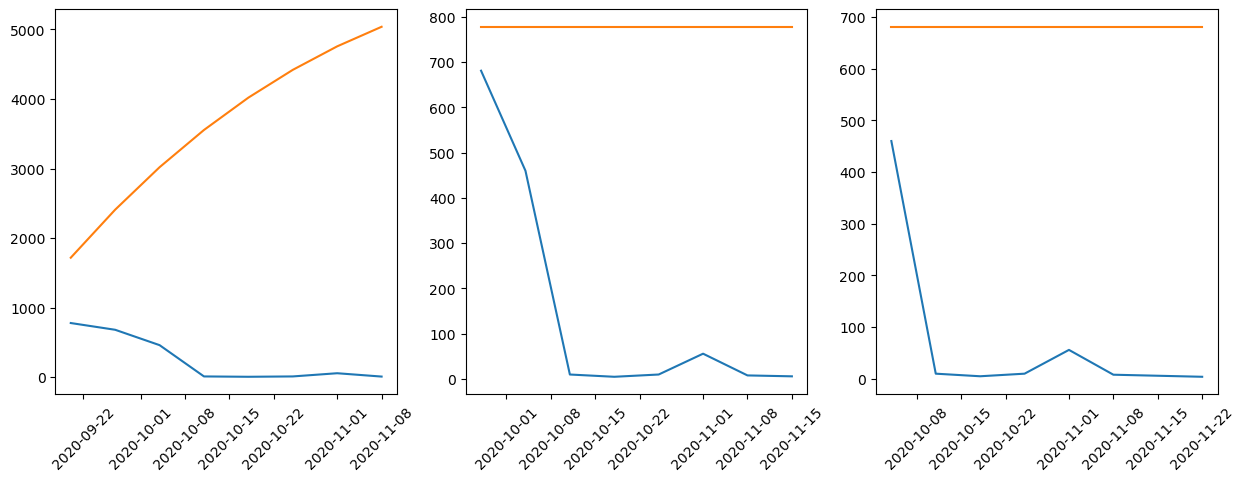

In [42]:
h = 8
n_windows = 3
lst = [cv[cv["unique_id"] == prod_idx[k]][i:i+h] for i in range(0, h * n_windows - 1, h)]

fig, axs = plt.subplots(1, n_windows, figsize=(15, 5))

for i, d in enumerate(lst):
    axs[i].plot(d.ds, d.y)
    axs[i].plot(d.ds, d.AutoARIMA)
    axs[i].tick_params("x", labelrotation=45)


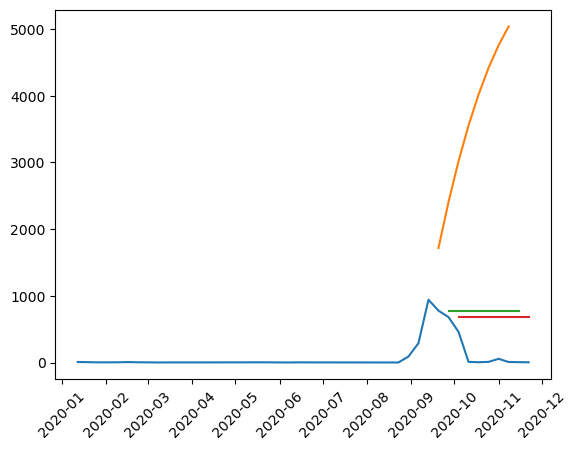

In [43]:
plt.plot(prod_list[prod_idx[k]]);
plt.xticks(rotation=45);

for i in range(n_windows):
    plt.plot(lst[i].ds, lst[i].AutoARIMA)